# TC-Former: Spectral Channel Mixing Transformer
Implementation based on: *Spectral Channel Mixing Transformer with Spectral-Center Attention for Hyperspectral Image Classification*

**Pipeline:** PCA → Conv2D Stem → TimeMixFormer → HyperMixFormer → Center Attention → MLP Head

In [1]:
import os
import numpy as np
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

torch.manual_seed(42)
np.random.seed(42)

# Device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    accelerator, device = 'mps', torch.device('mps')
elif torch.cuda.is_available():
    accelerator, device = 'gpu', torch.device('cuda')
else:
    accelerator, device = 'cpu', torch.device('cpu')
print(f'Accelerator: {accelerator}  |  Device: {device}')

Accelerator: mps  |  Device: mps


## 1. Configuration

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    dataset: str = 'IP'
    data_path: str = 'data'
    # Architecture — Table 2 from paper
    patch_size: int = 15        # IP:15  PU:24  WHHH:30
    pca_components: int = 150   # IP:150 PU:20  WHHH:135
    kernel_size: int = 9        # IP:9   PU:17  WHHH:19
    hidden_dim: int = 64
    num_heads: int = 1
    dropout: float = 0.1
    num_classes: int = 16       # IP:16  PU:9   WHHH:22
    depth: int = 2              # paper: "depth was set to 2"
    # Training
    batch_size: int = 200       # IP:200 PU:100 WHHH:20
    lr: float = 5e-4
    epochs: int = 200           # max epochs (early stopping will cut short)
    weight_decay: float = 1e-4
    patience: int = 20          # early stopping: epochs without val_OA improvement
    num_train_per_class: int = 10
    num_val_per_class: int = 5
    seed: int = 42

CONFIGS = {
    'IP':   Config(dataset='IP',   patch_size=15, pca_components=150, kernel_size=9,  num_classes=16, batch_size=200),
    'PU':   Config(dataset='PU',   patch_size=24, pca_components=20,  kernel_size=17, num_classes=9,  batch_size=100),
    'WHHH': Config(dataset='WHHH', patch_size=30, pca_components=135, kernel_size=19, num_classes=22, batch_size=20),
}

cfg = CONFIGS['IP']  # change to 'PU' or 'WHHH' as needed
print(cfg)

Config(dataset='IP', data_path='data', patch_size=15, pca_components=150, kernel_size=9, hidden_dim=64, num_heads=1, dropout=0.1, num_classes=16, depth=2, batch_size=200, lr=0.0005, epochs=200, weight_decay=0.0001, patience=20, num_train_per_class=10, num_val_per_class=5, seed=42)


## 2. Data Loading

In [3]:
def load_dataset(name, data_path='data'):
    if name == 'IP':
        d = scipy.io.loadmat(os.path.join(data_path, 'IP', 'Indian_pines_corrected.mat'))
        hsi = d['indian_pines_corrected']
        labels = np.load(os.path.join(data_path, 'IP', 'IPgt.npy'))
    elif name == 'PU':
        d = scipy.io.loadmat(os.path.join(data_path, 'PaviaU.mat'))
        g = scipy.io.loadmat(os.path.join(data_path, 'PaviaU_gt.mat'))
        hsi, labels = d['paviaU'], g['paviaU_gt']
    elif name == 'WHHH':
        d = scipy.io.loadmat(os.path.join(data_path, 'WHU_Hi_HongHu.mat'))
        g = scipy.io.loadmat(os.path.join(data_path, 'WHU_Hi_HongHu_gt.mat'))
        hsi, labels = d['WHU_Hi_HongHu'], g['WHU_Hi_HongHu_gt']
    else:
        raise ValueError(f'Unknown dataset: {name}')
    hsi    = hsi.astype(np.float32)
    labels = labels.astype(np.int64)
    print(f'[{name}] HSI {hsi.shape}  Labels {labels.shape}  '
          f'Labeled px: {(labels>0).sum()}')
    return hsi, labels

try:
    hsi, labels = load_dataset(cfg.dataset, cfg.data_path)
except FileNotFoundError as e:
    print(f'Data not found: {e}\nPlace data files in data/ and re-run.')

[IP] HSI (145, 145, 200)  Labels (145, 145)  Labeled px: 10249


## 3. PCA Preprocessing

In [4]:
def apply_pca(hsi, n_components):
    H, W, C = hsi.shape
    flat = hsi.reshape(-1, C)
    flat = (flat - flat.mean(0)) / (flat.std(0) + 1e-8)
    pca  = PCA(n_components=n_components, svd_solver='randomized', random_state=42)
    out  = pca.fit_transform(flat).reshape(H, W, n_components).astype(np.float32)
    print(f'PCA {C} -> {n_components}  explained variance: {pca.explained_variance_ratio_.sum():.3f}')
    return out, pca

hsi_pca, pca_model = apply_pca(hsi, cfg.pca_components)

PCA 200 -> 150  explained variance: 1.000


## 4. Dataset & DataLoaders

In [5]:
def create_split(labels, n_train_per_class, n_val_per_class=5, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for cls in range(1, labels.max() + 1):
        pos = np.argwhere(labels == cls)
        if len(pos) == 0:
            continue
        pos = pos[rng.permutation(len(pos))]
        n_tr  = min(n_train_per_class, len(pos))
        n_val = min(n_val_per_class, max(0, len(pos) - n_tr))
        train_idx.extend(pos[:n_tr].tolist())
        val_idx.extend(pos[n_tr:n_tr + n_val].tolist())
        test_idx.extend(pos[n_tr + n_val:].tolist())
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)


class HSIPatchDataset(Dataset):
    def __init__(self, hsi_pca, labels, indices, patch_size):
        pad = patch_size // 2
        self.labels  = labels
        self.indices = indices
        self.pad     = pad
        self.ps      = patch_size
        self.hsi = np.pad(hsi_pca, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        r, c   = self.indices[idx]
        label  = int(self.labels[r, c]) - 1
        rp, cp = r + self.pad, c + self.pad
        patch  = self.hsi[rp-self.pad:rp+self.pad+1, cp-self.pad:cp+self.pad+1, :]
        return torch.from_numpy(patch.copy()).permute(2, 0, 1), torch.tensor(label, dtype=torch.long)


train_idx, val_idx, test_idx = create_split(
    labels,
    n_train_per_class=cfg.num_train_per_class,
    n_val_per_class=cfg.num_val_per_class,
    seed=cfg.seed,
)
print(f'Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}')

train_ds = HSIPatchDataset(hsi_pca, labels, train_idx, cfg.patch_size)
val_ds   = HSIPatchDataset(hsi_pca, labels, val_idx,   cfg.patch_size)
test_ds  = HSIPatchDataset(hsi_pca, labels, test_idx,  cfg.patch_size)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  Test batches: {len(test_loader)}')

Train: 160  Val: 80  Test: 10009
Train batches: 1  Val batches: 1  Test batches: 51


## 5. Model Architecture
### 5.1 WKV Operator (RWKV-style causal time decay)

In [6]:
class WKVOperator(nn.Module):
    """
    RWKV-4 WKV (Eq. 5) — fully vectorized, no Python loop.

    For causal positions (t > s):  decay[t,s,c] = exp((t-s-1)*w[c])
    For non-causal (t <= s):       decay[t,s,c] = 0

    IMPORTANT: we mask non-causal exponents to -inf BEFORE exp()
    so that exp(-inf)=0. Without this, exp(+large) * False = Inf*0 = NaN
    on MPS/CUDA, which kills all gradients.
    """
    def __init__(self, dim):
        super().__init__()
        self.w_log = nn.Parameter(torch.zeros(dim))   # w = -exp(w_log) < 0
        self.u     = nn.Parameter(torch.zeros(dim))

    def forward(self, k, v):
        B, T, C = k.shape
        w = -torch.exp(self.w_log)  # (C,) negative decay per channel

        # Exponents for all (t, s) pairs: (T, T, C)
        idx = torch.arange(T, device=k.device, dtype=k.dtype)
        exp = (idx.unsqueeze(1) - idx.unsqueeze(0) - 1).unsqueeze(-1) * w

        # Causal mask: True where t > s (valid past token)
        causal = (idx.unsqueeze(1) > idx.unsqueeze(0))       # (T, T)

        # Set non-causal exponents to -inf so exp(-inf) = 0  (avoids Inf*0 = NaN)
        exp_safe = exp.masked_fill(~causal.unsqueeze(-1).expand_as(exp), float('-inf'))
        decay = torch.exp(exp_safe)                           # (T, T, C), causal, ≤ 1

        # Vectorized: A[b,t,c] = Σ_{s<t} decay[t,s,c] * exp(k[b,s,c]) * v[b,s,c]
        ek     = torch.exp(k)                                 # (B, T, C)
        d_perm = decay.permute(2, 0, 1)                       # (C, T, T)
        A      = torch.bmm(d_perm, (ek * v).permute(2, 1, 0)).permute(2, 1, 0)   # (B,T,C)
        B_den  = torch.bmm(d_perm, ek.permute(2, 1, 0)).permute(2, 1, 0)         # (B,T,C)

        euk = torch.exp(self.u + k)                           # current-token bonus
        return (A + euk * v) / (B_den + euk + 1e-8)

### 5.2 TimeMixing (Eq. 2-6)

In [7]:
class TimeMixing(nn.Module):
    """
    r_t = W_r  (mu_r  x_t + (1-mu_r)  x_{t-1})
    k_t = W_k  (mu_k  x_t + (1-mu_k)  x_{t-1})
    v_t = W_v  (mu_v  x_t + (1-mu_v)  x_{t-1})
    o_t = W_o ( sigma(r_t) * WKV(k,v)_t )
    All W_r/W_k/W_v are learnable element-wise vectors (not matrices).
    """
    def __init__(self, dim):
        super().__init__()
        self.mu_r = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.mu_k = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.mu_v = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.W_r  = nn.Parameter(torch.ones(1,1,dim))
        self.W_k  = nn.Parameter(torch.ones(1,1,dim))
        self.W_v  = nn.Parameter(torch.ones(1,1,dim))
        self.W_o  = nn.Linear(dim, dim, bias=False)
        self.wkv  = WKVOperator(dim)

    @staticmethod
    def _shift(x):
        return torch.cat([torch.zeros_like(x[:,:1,:]), x[:,:-1,:]], dim=1)

    def forward(self, x):
        p = self._shift(x)
        r = self.W_r * (self.mu_r * x + (1 - self.mu_r) * p)
        k = self.W_k * (self.mu_k * x + (1 - self.mu_k) * p)
        v = self.W_v * (self.mu_v * x + (1 - self.mu_v) * p)
        return self.W_o(torch.sigmoid(r) * self.wkv(k, v))

### 5.3 HyperMixing (Eq. 7-10)

In [8]:
class HyperMixing(nn.Module):
    """
    Equations 8-10 from paper.

    r'_t = W'_r (mu'_r * x_t + (1-mu'_r) * x_{t-1})          Eq. 8
    k'_t = W'_k (mu'_k * x_t + (1-mu'_k) * x_{t-1})          Eq. 9
    v'_t = WKV(k'_t, x_t)    -- x used directly as values     Eq. 5
    o'_t = sigma(r'_t) * W_h( Mish(k'_t) * v'_t )             Eq. 10

    No separate v-projection (only r' and k' defined in paper Eqs 8-9).
    WKV uses x as values, matching "input features processed by WKV operator".
    """
    def __init__(self, dim):
        super().__init__()
        self.mu_r = nn.Parameter(torch.full((1, 1, dim), 0.5))
        self.mu_k = nn.Parameter(torch.full((1, 1, dim), 0.5))
        self.W_r  = nn.Parameter(torch.ones(1, 1, dim))
        self.W_k  = nn.Parameter(torch.ones(1, 1, dim))
        self.W_h  = nn.Linear(dim, dim, bias=False)
        self.mish = nn.Mish()
        self.wkv  = WKVOperator(dim)

    @staticmethod
    def _shift(x):
        return torch.cat([torch.zeros_like(x[:, :1, :]), x[:, :-1, :]], dim=1)

    def forward(self, x):
        p = self._shift(x)
        r = self.W_r * (self.mu_r * x + (1 - self.mu_r) * p)
        k = self.W_k * (self.mu_k * x + (1 - self.mu_k) * p)
        v_prime = self.wkv(k, x)                        # WKV with k' as key, x as value
        return torch.sigmoid(r) * self.W_h(self.mish(k) * v_prime)

### 5.4 Tiny Attention

In [9]:
class TinyAttention(nn.Module):
    """
    Lightweight MHA: single fused QKV linear -> chunk -> scaled dot-product -> linear out.
    """
    def __init__(self, dim, num_heads=1):
        super().__init__()
        assert dim % num_heads == 0
        self.H     = num_heads
        self.D     = dim // num_heads
        self.scale = self.D ** -0.5
        self.qkv   = nn.Linear(dim, 3*dim, bias=False)
        self.proj  = nn.Linear(dim, dim,   bias=False)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.H, self.D).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)                      # each (B, H, T, D)
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = attn.softmax(dim=-1)
        out  = (attn @ v).transpose(1,2).reshape(B, T, C)
        return self.proj(out)

### 5.5 TimeMixFormer & HyperMixFormer Blocks (x2 each, Figure b/c)

In [ ]:
class TimeMixFormerBlock(nn.Module):
    """Pre-norm: 2x TimeMixing (residual) + Tiny Attention (residual)."""
    def __init__(self, dim, num_heads=1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.tm1   = TimeMixing(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.tm2   = TimeMixing(dim)
        self.norm3 = nn.LayerNorm(dim)
        self.attn  = TinyAttention(dim, num_heads)

    def forward(self, x):
        x = x + self.tm1(self.norm1(x))
        x = x + self.tm2(self.norm2(x))
        x = x + self.attn(self.norm3(x))
        return x


class HyperMixFormerBlock(nn.Module):
    """
    Pre-norm: HyperMixing called 2× with SHARED weights + Tiny Attention (residual).
    Paper: "consecutively calling the HyperMixing module with shared parameters twice."
    """
    def __init__(self, dim, num_heads=1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)
        self.hm    = HyperMixing(dim)      # single module, called twice — shared weights
        self.attn  = TinyAttention(dim, num_heads)

    def forward(self, x):
        x = x + self.hm(self.norm1(x))    # first pass
        x = x + self.hm(self.norm2(x))    # second pass, same weights
        x = x + self.attn(self.norm3(x))
        return x

### 5.6 Center Attention
Central pixel → Query; all spatial tokens → Key/Value. Ablation shows −3.14% OA on IP when removed.

In [11]:
class CenterAttention(nn.Module):
    """
    Central token as Q; all tokens as K, V.
    Outputs a single (B, C) center-pixel representation.
    """
    def __init__(self, dim, patch_size, num_heads=1):
        super().__init__()
        assert dim % num_heads == 0
        self.H          = num_heads
        self.D          = dim // num_heads
        self.scale      = self.D ** -0.5
        self.center_idx = (patch_size // 2) * patch_size + (patch_size // 2)
        self.norm    = nn.LayerNorm(dim)
        self.q_proj  = nn.Linear(dim, dim, bias=False)
        self.kv_proj = nn.Linear(dim, 2*dim, bias=False)
        self.proj    = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        # x: (B, T, C)
        B, T, C = x.shape
        xn = self.norm(x)
        center = xn[:, self.center_idx, :].unsqueeze(1)         # (B, 1, C)

        q  = self.q_proj(center).reshape(B, 1, self.H, self.D).transpose(1,2)
        kv = self.kv_proj(xn)
        k, v = kv.chunk(2, dim=-1)
        k = k.reshape(B, T, self.H, self.D).transpose(1,2)
        v = v.reshape(B, T, self.H, self.D).transpose(1,2)

        attn = (q @ k.transpose(-2,-1)) * self.scale           # (B, H, 1, T)
        attn = attn.softmax(dim=-1)
        out  = (attn @ v).transpose(1,2).reshape(B, 1, C)
        out  = self.proj(out).squeeze(1)                        # (B, C)
        return out + x[:, self.center_idx, :]                   # residual

### 5.7 MLP Head
Linear + BatchNorm1D + Dropout + ReLU + Linear (paper legend)

In [12]:
class MLPHead(nn.Module):
    def __init__(self, in_dim, num_classes, dropout=0.1):
        super().__init__()
        h = in_dim * 4
        self.net = nn.Sequential(
            nn.Linear(in_dim, h),
            nn.BatchNorm1d(h),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(h, num_classes),
        )
    def forward(self, x): return self.net(x)

### 5.8 TC-Former — Full Model

In [13]:
class TCFormer(nn.Module):
    """
    Spectral Channel Mixing Transformer (TC-Former).

    Input  (B, C_pca, P, P)
      -> Conv2D Stem        (B, D, P, P)    Conv2D + BN2D + ReLU
      -> Flatten            (B, T, D)       T = P*P
      -> TimeMixFormer x depth              sequential stacked blocks
      -> HyperMixFormer x depth             sequential stacked blocks
      -> CenterAttention    (B, D)
      -> MLPHead            (B, num_classes)
    """
    def __init__(self, cfg):
        super().__init__()
        D     = cfg.hidden_dim
        depth = cfg.depth

        self.stem = nn.Sequential(
            nn.Conv2d(cfg.pca_components, D,
                      kernel_size=cfg.kernel_size,
                      padding=cfg.kernel_size // 2,
                      bias=False),
            nn.BatchNorm2d(D),
            nn.ReLU(inplace=True),
        )
        self.time_mix_formers  = nn.ModuleList(
            [TimeMixFormerBlock(D, cfg.num_heads) for _ in range(depth)]
        )
        self.hyper_mix_formers = nn.ModuleList(
            [HyperMixFormerBlock(D, cfg.num_heads) for _ in range(depth)]
        )
        self.center_attn = CenterAttention(D, cfg.patch_size, cfg.num_heads)
        self.head        = MLPHead(D, cfg.num_classes, cfg.dropout)

    def forward(self, x):
        x = self.stem(x)                          # (B, D, P, P)
        x = x.flatten(2).transpose(1, 2)          # (B, T, D)
        for block in self.time_mix_formers:
            x = block(x)
        for block in self.hyper_mix_formers:
            x = block(x)
        x = self.center_attn(x)                   # (B, D)
        return self.head(x)                        # (B, num_classes)


model  = TCFormer(cfg).to(device)
n_pars = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_pars:,}')
print(model)

Parameters: 909,968
TCFormer(
  (stem): Sequential(
    (0): Conv2d(150, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (time_mix_formers): ModuleList(
    (0-1): 2 x TimeMixFormerBlock(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (tm1): TimeMixing(
        (W_o): Linear(in_features=64, out_features=64, bias=False)
        (wkv): WKVOperator()
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (tm2): TimeMixing(
        (W_o): Linear(in_features=64, out_features=64, bias=False)
        (wkv): WKVOperator()
      )
      (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): TinyAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=False)
        (proj): Linear(in_features=64, out_features=64, bias=False)
      )
    )
  )
  (hyper_mix_formers): Mo

### 5.9 Lightning Module

In [14]:
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model on a DataLoader; returns (preds, trues) as numpy arrays."""
    model.eval()
    dev = next(model.parameters()).device
    preds, trues = [], []
    for x, y in loader:
        preds.extend(model(x.to(dev)).argmax(1).cpu().tolist())
        trues.extend(y.tolist())
    return np.array(preds), np.array(trues)


def compute_metrics(preds, trues, num_classes):
    oa = float((preds == trues).mean())
    try:
        kappa = float(cohen_kappa_score(trues, preds))
    except Exception:
        kappa = 0.0
    per_c = [
        float((preds[trues == c] == trues[trues == c]).mean())
        for c in range(num_classes) if (trues == c).sum() > 0
    ]
    return dict(OA=oa, AA=float(np.mean(per_c)) if per_c else 0.0,
                Kappa=kappa, per_class=per_c)

In [15]:
class TCFormerLit(L.LightningModule):
    """
    PyTorch Lightning wrapper for TC-Former.
    Handles training/validation loops, metric logging, and optimizer scheduling.
    """
    def __init__(self, cfg):
        super().__init__()
        self.cfg   = cfg
        self.model = TCFormer(cfg)
        self.criterion = nn.CrossEntropyLoss()
        self._val_preds: list = []
        self._val_trues: list = []

    def forward(self, x):
        return self.model(x)

    # ── Training ──────────────────────────────────────────────────────────────
    def training_step(self, batch, _):
        x, y   = batch
        logits = self(x)
        loss   = self.criterion(logits, y)
        acc    = (logits.argmax(1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_acc',  acc,  prog_bar=True, on_step=False, on_epoch=True)
        return loss

    # ── Validation ────────────────────────────────────────────────────────────
    def validation_step(self, batch, _):
        x, y = batch
        logits = self(x)
        self._val_preds.append(logits.argmax(1).cpu())
        self._val_trues.append(y.cpu())

    def on_validation_epoch_end(self):
        if not self._val_preds:
            return
        preds = torch.cat(self._val_preds).numpy()
        trues = torch.cat(self._val_trues).numpy()
        m = compute_metrics(preds, trues, self.cfg.num_classes)
        self.log('val_OA',    m['OA'],    prog_bar=True)
        self.log('val_AA',    m['AA'],    prog_bar=False)
        self.log('val_kappa', m['Kappa'], prog_bar=False)
        self._val_preds.clear()
        self._val_trues.clear()

    # ── Optimizer + Scheduler ─────────────────────────────────────────────────
    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.parameters(), lr=self.cfg.lr, weight_decay=self.cfg.weight_decay
        )
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.cfg.epochs)
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': sched, 'interval': 'epoch'}}

In [16]:
class EpochLogger(L.Callback):
    """Prints a clean one-line summary every `log_every` epochs."""
    def __init__(self, log_every=10):
        self.log_every = log_every

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.log_every != 0 and epoch != 1:
            return
        m = trainer.callback_metrics
        print(
            f'[{epoch:>3d}/{trainer.max_epochs}] '
            f'loss={m.get("train_loss", float("nan")):.4f}  '
            f'acc={m.get("train_acc", float("nan")):.4f}  '
            f'val_OA={m.get("val_OA", float("nan")):.4f}  '
            f'val_AA={m.get("val_AA", float("nan")):.4f}  '
            f'kappa={m.get("val_kappa", float("nan")):.4f}'
        )


ckpt_dir = f'checkpoints/{cfg.dataset}'

checkpoint_cb = ModelCheckpoint(
    dirpath=ckpt_dir,
    monitor='val_OA',
    mode='max',
    save_top_k=1,
    filename='best-{epoch:03d}-{val_OA:.4f}',
    verbose=False,
)

early_stop_cb = EarlyStopping(
    monitor='val_OA',
    mode='max',
    patience=cfg.patience,
    verbose=False,
)

logger = CSVLogger('logs', name=cfg.dataset)

trainer = L.Trainer(
    max_epochs=cfg.epochs,
    accelerator=accelerator,
    devices=1,
    callbacks=[checkpoint_cb, early_stop_cb, EpochLogger(log_every=10)],
    logger=logger,
    log_every_n_steps=1,
    enable_progress_bar=False,
    enable_model_summary=False,
    num_sanity_val_steps=0,
)

print(f'Training {cfg.dataset} | max {cfg.epochs} epochs | early stop patience={cfg.patience}')
lit_model = TCFormerLit(cfg)
trainer.fit(lit_model, train_loader, test_loader)

best_oa = float(checkpoint_cb.best_model_score) if checkpoint_cb.best_model_score else 0.0
print(f'\nDone. Best val_OA={best_oa:.4f}  checkpoint: {checkpoint_cb.best_model_path}')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training IP | max 200 epochs | early stop patience=20
[  1/200] loss=2.8244  acc=0.0688  val_OA=0.0626  val_AA=0.2163  kappa=0.0338
[ 10/200] loss=1.0602  acc=0.9750  val_OA=0.4883  val_AA=0.7075  kappa=0.4494
[ 20/200] loss=0.4451  acc=1.0000  val_OA=0.6327  val_AA=0.7879  kappa=0.5926



Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

## 7. Evaluation

In [17]:
# Load best checkpoint and evaluate on test set
best_ckpt = checkpoint_cb.best_model_path
ckpt_data  = torch.load(best_ckpt, map_location='cpu', weights_only=False)
model_best = TCFormer(cfg).to(device)
state = {k[len('model.'):]: v
         for k, v in ckpt_data['state_dict'].items()
         if k.startswith('model.')}
model_best.load_state_dict(state)

preds, trues = evaluate(model_best, test_loader)
m = compute_metrics(preds, trues, cfg.num_classes)

print(f'=== Final Test Results [{cfg.dataset}] ===')
print(f'OA    : {m["OA"]*100:.2f}%')
print(f'AA    : {m["AA"]*100:.2f}%')
print(f'Kappa : {m["Kappa"]:.4f}')
print()
print('Paper targets (supervised, 10 samples/class):')
print('  IP  : OA 90.01%  AA 94.36%  kappa 0.887')
print('  PU  : OA 94.60%  AA 95.20%  kappa 0.930')
print('  WHHH: OA 91.56%  AA 90.54%  kappa 0.894')
print()
print('Per-class accuracy:')
for i, a in enumerate(m['per_class']):
    print(f'  Class {i+1:>2d}: {a*100:.1f}%')

=== Final Test Results [IP] ===
OA    : 63.60%
AA    : 78.84%
Kappa : 0.5956

Paper targets (supervised, 10 samples/class):
  IP  : OA 90.01%  AA 94.36%  kappa 0.887
  PU  : OA 94.60%  AA 95.20%  kappa 0.930
  WHHH: OA 91.56%  AA 90.54%  kappa 0.894

Per-class accuracy:
  Class  1: 100.0%
  Class  2: 21.4%
  Class  3: 56.8%
  Class  4: 92.3%
  Class  5: 87.2%
  Class  6: 92.9%
  Class  7: 100.0%
  Class  8: 94.8%
  Class  9: 100.0%
  Class 10: 85.2%
  Class 11: 50.5%
  Class 12: 37.2%
  Class 13: 98.4%
  Class 14: 87.8%
  Class 15: 56.9%
  Class 16: 100.0%


## 8. Visualisation

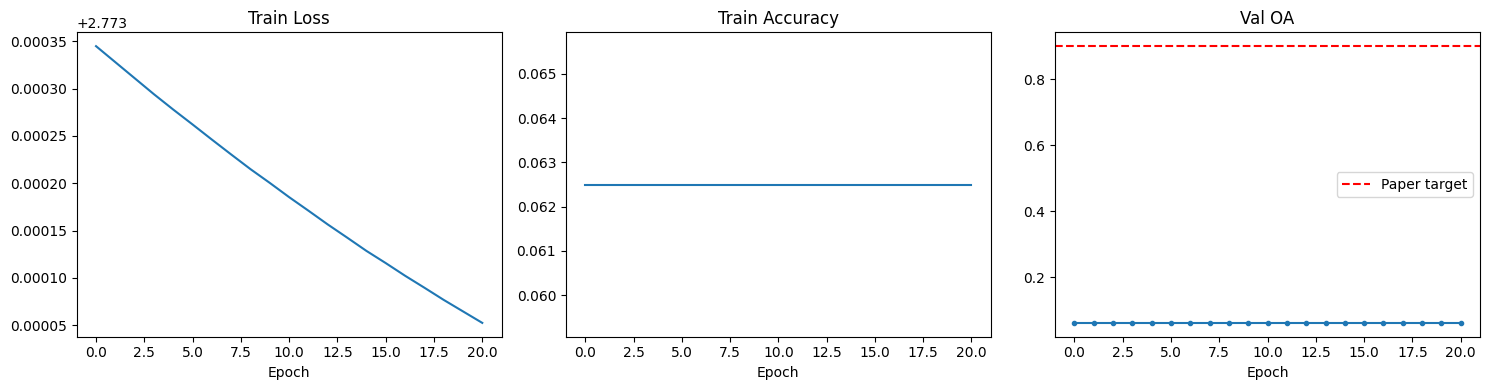

In [ ]:
# Read training history from CSVLogger and plot
log_csv = f'logs/{cfg.dataset}/version_0/metrics.csv'
df = pd.read_csv(log_csv)

train_df = df.dropna(subset=['train_loss']).reset_index(drop=True)
val_df   = df.dropna(subset=['val_OA']).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_df['epoch'], train_df['train_loss'])
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch')

axes[1].plot(train_df['epoch'], train_df['train_acc'])
axes[1].set_title('Train Accuracy'); axes[1].set_xlabel('Epoch')

axes[2].plot(val_df['epoch'], val_df['val_OA'], marker='o', markersize=3)
axes[2].set_title('Val OA'); axes[2].set_xlabel('Epoch')
axes[2].axhline(0.9001, color='red', linestyle='--', label='Paper target')
axes[2].legend()

plt.tight_layout(); plt.show()

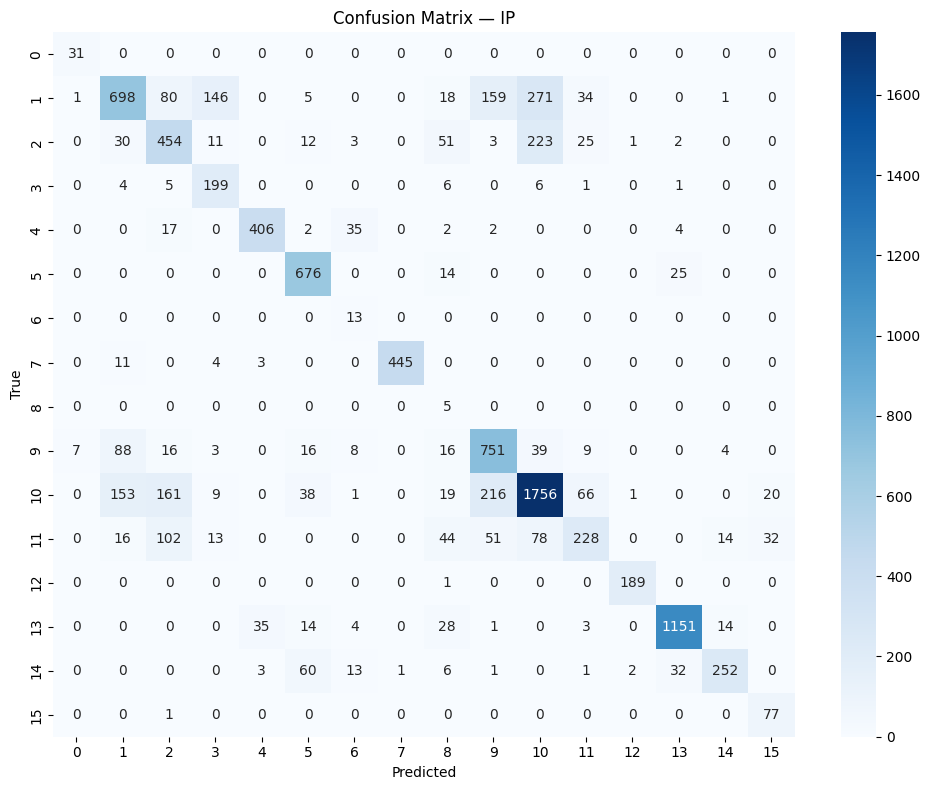

In [ ]:
cm = confusion_matrix(trues, preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {cfg.dataset}')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

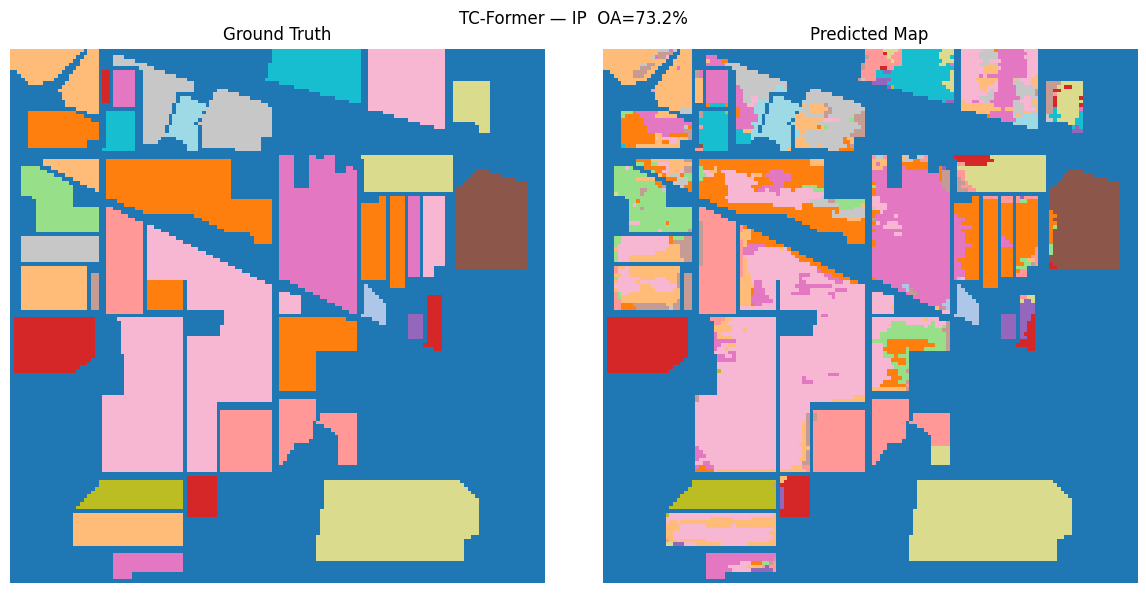

In [ ]:
@torch.no_grad()
def predict_full_image(model, hsi_pca, labels, patch_size, batch_size=512):
    H, W = labels.shape
    pad  = patch_size // 2
    phsi = np.pad(hsi_pca, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    coords   = [(r, c) for r in range(H) for c in range(W) if labels[r, c] > 0]
    pred_map = np.zeros((H, W), dtype=np.int64)
    dev = next(model.parameters()).device
    model.eval()
    for s in range(0, len(coords), batch_size):
        batch   = coords[s:s + batch_size]
        patches = []
        for r, c in batch:
            rp, cp = r + pad, c + pad
            p = phsi[rp-pad:rp+pad+1, cp-pad:cp+pad+1, :]
            patches.append(torch.from_numpy(p.copy()).permute(2, 0, 1))
        pr = model(torch.stack(patches).to(dev)).argmax(1).cpu().numpy()
        for (r, c), pred in zip(batch, pr):
            pred_map[r, c] = pred + 1
    return pred_map

pred_map = predict_full_image(model_best, hsi_pca, labels, cfg.patch_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(labels,   cmap='tab20'); axes[0].set_title('Ground Truth');  axes[0].axis('off')
axes[1].imshow(pred_map, cmap='tab20'); axes[1].set_title('Predicted Map'); axes[1].axis('off')
plt.suptitle(f'TC-Former — {cfg.dataset}  OA={m["OA"]*100:.1f}%')
plt.tight_layout(); plt.show()

## 9. Save Checkpoint

In [ ]:
# Checkpoint is auto-saved by ModelCheckpoint.
# To reload manually later:
#
#   ckpt = torch.load('checkpoints/IP/best-epoch=XXX-val_OA=X.XXXX.ckpt', weights_only=False)
#   model = TCFormer(cfg).to(device)
#   state = {k[len('model.'):]: v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
#   model.load_state_dict(state)

print(f'Best checkpoint: {checkpoint_cb.best_model_path}')
print(f'Logs           : logs/{cfg.dataset}/version_0/metrics.csv')

Best checkpoint: /Users/macarchic/Documents/unik/cursova_hsi/checkpoints/IP/best-epoch=054-val_OA=0.8875.ckpt
Logs           : logs/IP/version_0/metrics.csv
